In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os 
os.chdir('..')

In [49]:
import torch
from sklearn.model_selection import train_test_split
from fq_model.fq_tsk_regression import FQ_regression
import torch.nn.functional as F
from sklearn.metrics import accuracy_score, mean_squared_error
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

In [50]:
from regression.cal_house.cal_housing import CalHousing
X, y = CalHousing().get_data()

In [51]:
X.std(axis=0)

array([0.19955467, 0.22702395, 0.2468921 , 0.05557801, 0.06539025,
       0.03176044, 0.06286628, 0.13098059, 0.35502503])

In [52]:
y.std()

0.2380048790064407

In [53]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# device = "cpu"
print(device)
test_size=0.2
batch_size=200
random_state=17
num_epochs=190
rules=3
lr=0.001

cuda


In [54]:
train_loss = []
test_loss = []

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.5,
                                                    random_state=random_state)
    
X_train = torch.Tensor(X_train).to(device)
X_test = torch.Tensor(X_test).to(device)
y_train = torch.Tensor(y_train).to(device)
y_test = torch.Tensor(y_test).to(device)

out_size = 1
print('out_size', out_size)

# Initialize and move model to GPU
model = FQ_regression(in_features=X.shape[1],
                      rules=rules,
                      out_features=out_size,
                      device=device).to(device)

# Initialize Adam optimizer
optimizer = optim.RMSprop(model.parameters(), lr=lr)

for epoch in range(num_epochs):
    model.train()
    for i in range(0, len(X_train), batch_size):
        optimizer.zero_grad()
        batch_X, batch_y = X_train[i:i+batch_size], y_train[i:i+batch_size]
        outputs = model(batch_X)
        mse_loss = F.mse_loss(outputs, batch_y)
        total_loss = mse_loss  
        total_loss.backward()
        # print(model.tt.grad)
        optimizer.step()

    model.eval()
    with torch.no_grad():
        outputs = model(X_test)
        mse_loss = F.mse_loss(outputs, y_test)
        total_loss = mse_loss
        test_loss.append(total_loss.item())
        #####
        outputs = model(X_train)
        mse_loss = F.mse_loss(outputs, y_train)
        total_loss = mse_loss
        train_loss.append(total_loss.item())


train_loss = np.sqrt(train_loss)
test_loss = np.sqrt(test_loss)

# Calculate and print the average accuracy across all folds
min_RMSE = min(test_loss)
print("minimum test RMSE:", min_RMSE)
min_RMSE = min(train_loss)
print("minimum train RMSE:", min_RMSE)

out_size 1


KeyboardInterrupt: 

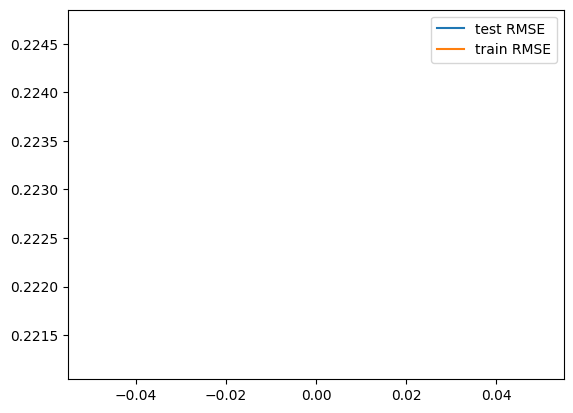

In [ ]:
plt.plot(np.arange(len(test_loss)), test_loss)
plt.plot(np.arange(len(train_loss)), train_loss)
plt.legend(['test RMSE', 'train RMSE'])
plt.show()

In [ ]:
model.std

Parameter containing:
tensor([[[ 0.6462,  0.8307, -0.0104],
         [ 0.2157,  0.8625,  0.9523],
         [ 0.7797,  0.5922,  0.3483],
         [ 0.1686,  0.7854,  0.5425],
         [ 0.1275,  0.4400,  0.4655],
         [ 0.4385,  0.5281,  0.4924],
         [ 0.7846,  0.1355,  0.4558],
         [ 0.6777,  0.4183,  0.2489],
         [ 0.7837,  1.0448,  0.2291]]], device='cuda:0', requires_grad=True)

In [ ]:
model.mean

Parameter containing:
tensor([[[0.5058, 0.1970, 0.6943],
         [0.5190, 1.0079, 0.8983],
         [0.1718, 1.0044, 0.0360],
         [0.7326, 0.7570, 0.8271],
         [0.5428, 0.4572, 0.7879],
         [0.6831, 0.1105, 0.6331],
         [0.8174, 0.1889, 0.5446],
         [0.4748, 0.6829, 0.0558],
         [0.9625, 0.5368, 0.3128]]], device='cuda:0', requires_grad=True)

In [ ]:
torch.tanh(model.tt)

tensor([[[-0.1311,  0.1085, -0.0733],
         [ 0.0780,  0.1820,  0.1534],
         [ 0.1186,  0.1629,  0.0060],
         [ 0.0664,  0.1103, -0.0007],
         [ 0.2366,  0.1698,  0.0490],
         [-0.1496, -0.1578,  0.0634],
         [ 0.2999, -0.2187,  0.0023],
         [-0.1183, -0.1770, -0.0316],
         [ 0.0940, -0.2072, -0.0933]]], device='cuda:0',
       grad_fn=<TanhBackward0>)

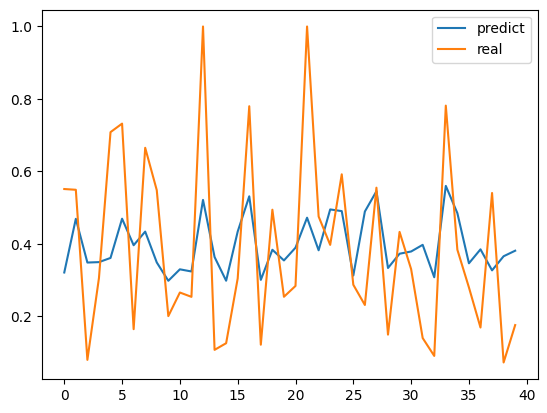

In [ ]:
model.eval()
plt.plot(np.array(model(X_test).detach().to('cpu'))[40:80])
plt.plot(y_test.cpu()[40:80])
plt.legend(['predict', 'real'])

In [ ]:
np.sqrt(mean_squared_error(np.array(model(X_test).detach().to('cpu')), y_test.cpu()))

0.22467922

IRIS = 94</br>
Cryotheraphy = 95</br>
Immunotherapy = 89</br>
Haberman = 74</br>
Wine = 89</br>
heart = 85</br>
CAL HOUSING : tsk:0.34, mamdani=0.33

In [ ]:
np.sqrt(13147696128.0) / y.mean()

289848.9058780048